# Notebook for testing aspects of the Diffusers library
Current list of sections:
1. VAE

## VAE

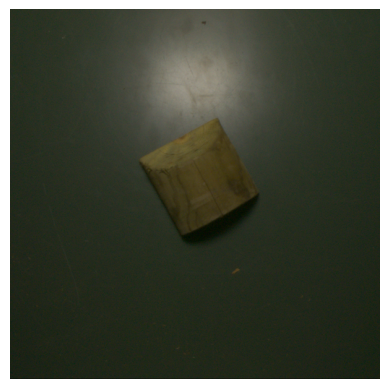

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027084291..0.6212488].


Latents shape: torch.Size([1, 4, 64, 64])
Reconstructed image shape: torch.Size([1, 3, 512, 512])


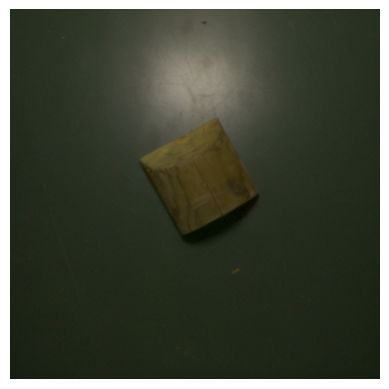

In [3]:
# Change working directory to parent directory
import os
os.chdir("/media/aris/Data/master2025dev/aris_master")
device = "cuda"
from diffusers import AutoencoderKL

# ----------- Download model from Hugging Face and save it locally ----------- #
"""
# url = "https://huggingface.co/stabilityai/sd-vae-ft-mse-original/blob/main/vae-ft-mse-840000-ema-pruned.safetensors"  # can also be a local file
# model = AutoencoderKL.from_single_file(url)
# Save the model to current working directory
# save_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
# model.save_pretrained(save_path)

# Print files in the specified directory
# vae_directory = os.path.join(os.getcwd(), "models/VAE/")
# print("Files in VAE directory:", os.listdir(vae_directory))
"""

# # --------------------------- import model locally --------------------------- #
local_model_path = os.path.join(os.getcwd(), "models/VAE/vae-ft-mse-840000-ema-pruned")
vae = AutoencoderKL.from_pretrained(local_model_path)
vae.to(device)

# # Test the model by printing its configuration
# print("Model configuration:", model.config)

# Test the model with image
img_path = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories_512x512/train/impregnated_wood/images/img_bold-eagle_2024-11-04T16-33-09-968.png"
from PIL import Image
image = Image.open(img_path).convert("RGB")

#convert image to tensor
from torchvision import transforms
transform = transforms.Compose([
    # transforms.Resize((600, 960)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
image = transform(image).unsqueeze(0).to(device)

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_input.png"
#Limit image to valid range and convert to PIL
img = (image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
img = transforms.ToPILImage()(img)
img.save(save_path)


# plot image 
import matplotlib.pyplot as plt
plt.imshow((image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()
# latents = model.encode(image)


# ---------------------------------- encode ---------------------------------- #
import torch    
with torch.no_grad():
    latents = vae.encode(image).latent_dist.sample()
print("Latents shape:", latents.shape)

# ---------------------------------- decode ---------------------------------- #
with torch.no_grad():
    reconstructed_image = vae.decode(latents).sample
    
print("Reconstructed image shape:", reconstructed_image.shape)
# plot reconstructed image
plt.imshow((reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5))
plt.axis('off')
plt.show()

#save
save_path = "/media/aris/Data/master2025dev/outputs/visualizations/VAE_half_res_test_output.png"
#Limit image to valid range and convert to PIL
img = (reconstructed_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).clip(0, 1)
reconstructed_image_pil = transforms.ToPILImage()(img)
reconstructed_image_pil.save(save_path)






#vae.to("cpu")




## Debugging attempt of the green hue of the VAE
I suspect the green hue of the vae could come from the transform in the dataloader. Following code takes the dataloader and visualises the vae input-output

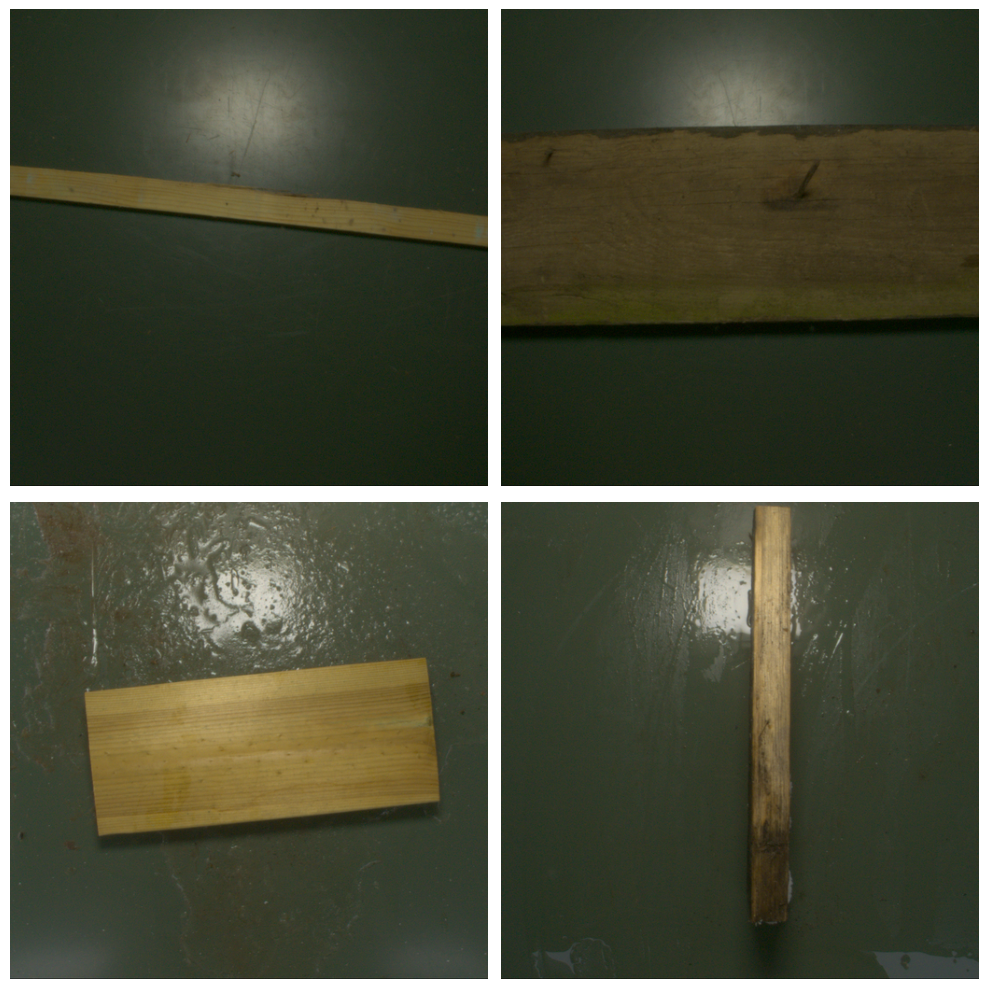

Input image shape: torch.Size([4, 3, 512, 512]), Latent shape: torch.Size([4, 4, 64, 64])
Latents shape: torch.Size([4, 4, 64, 64])
batch shape: torch.Size([4, 4, 64, 64])
Final decoded images shape: torch.Size([4, 3, 512, 512])


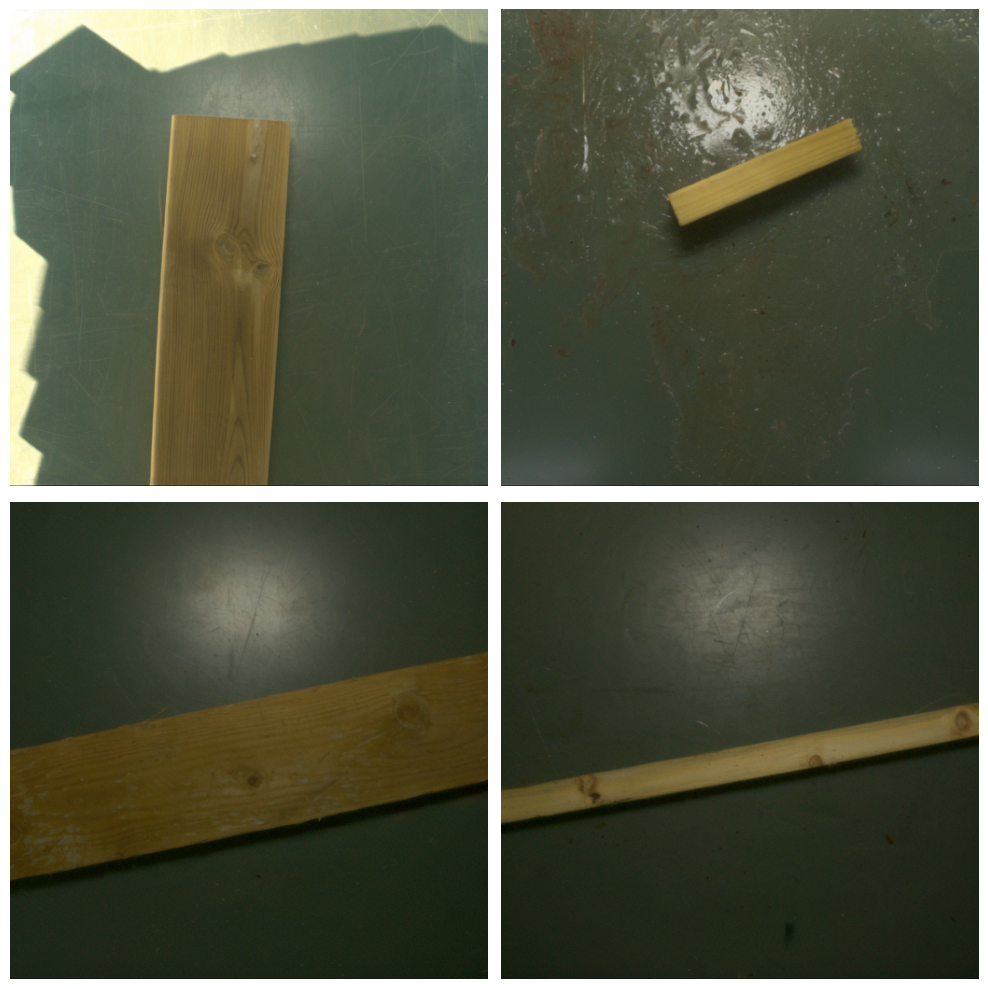

In [8]:
resolution = (512, 512)
center_crop = True
random_flip = True
preserve_input_precision = False
train_batch_size = 4
dataloader_num_workers = 4
dataset_dir = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories_512x512/train/impregnated_wood/images/"

import torch
from torchvision import transforms
import matplotlib.pyplot as plt
def _ensure_three_channels(tensor: torch.Tensor) -> torch.Tensor:
    """
    Ensure the tensor has exactly three channels (C, H, W) by repeating or truncating channels when needed.
    """
    if tensor.ndim == 2:
        tensor = tensor.unsqueeze(0)
    channels = tensor.shape[0]
    if channels == 3:
        return tensor
    if channels == 1:
        return tensor.repeat(3, 1, 1)
    if channels == 2:
        return torch.cat([tensor, tensor[:1]], dim=0)
    if channels > 3:
        return tensor[:3]
    raise ValueError(f"Unsupported number of channels: {channels}")

import numpy as np
def preview_dataloader(dataloader, num_images=8):
    """
    Preview images from the dataloader in a grid.
    
    Args:
        dataloader: PyTorch DataLoader object
        num_images: Number of images to display (default: 8)
    """
    # Get a batch from the dataloader
    batch = next(iter(dataloader))
    images = batch["input"]
    
    # Limit to num_images
    images = images[:num_images]
    
    # Denormalize images from [-1, 1] to [0, 1]
    images = (images + 1) / 2
    images = torch.clamp(images, 0, 1)
    
    # Create grid
    grid_size = int(np.ceil(np.sqrt(num_images)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flatten()
    
    for idx, ax in enumerate(axes):
        if idx < len(images):
            # Convert to numpy and transpose from CxHxW to HxWxC
            img = images[idx].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Preprocessing the datasets and DataLoaders creation.
spatial_augmentations = [
    transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(resolution) if center_crop else transforms.RandomCrop(resolution),
    transforms.RandomHorizontalFlip() if random_flip else transforms.Lambda(lambda x: x),
]

augmentations = transforms.Compose(
    spatial_augmentations
    + [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

precision_augmentations = transforms.Compose(
    [
        transforms.PILToTensor(),
        transforms.Lambda(_ensure_three_channels),
        transforms.ConvertImageDtype(torch.float32),
    ]
    + spatial_augmentations
    + [transforms.Normalize([0.5], [0.5])]
)

def transform_images(examples):
    processed = []
    for image in examples["image"]:
        if not preserve_input_precision:
            processed.append(augmentations(image.convert("RGB")))
        else:
            precise_image = image
            if precise_image.mode == "P":
                precise_image = precise_image.convert("RGB")
            processed.append(precision_augmentations(precise_image))
    return {"input": processed}

from datasets import load_dataset
# Load the dataset
dataset = load_dataset("imagefolder", data_dir=dataset_dir, split="train")
    

dataset.set_transform(transform_images)
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=train_batch_size, shuffle=True, num_workers=dataloader_num_workers
)
preview_dataloader(train_dataloader, num_images=4)


from diffusers import AutoencoderKL
local_model_path = "/media/aris/Data/master2025dev/aris_master/models/VAE/vae-ft-mse-840000-ema-pruned"
vae = AutoencoderKL.from_pretrained(local_model_path)
vae.to("cuda")

#check for image dimensions
test_batch = next(iter(train_dataloader))
test_images = test_batch["input"].to("cuda")
with torch.no_grad():
    latent_dist = vae.encode(test_images).latent_dist
    latents = latent_dist.sample() * vae.config.scaling_factor
print(f"Input image shape: {test_images.shape}, Latent shape: {latents.shape}")


# ---------------------------------- Decode ---------------------------------- #
# -------------------------------- ADDED CODE -------------------------------- #
print("Latents shape:", latents.shape)
# decode the latents with VAE in smaller batches to avoid OOM
decoded_images = []
vae_batch_size = 4  # Process 4 images at a time
with torch.no_grad():
    for i in range(0, len(latents), vae_batch_size):
        batch = latents[i:i+vae_batch_size] / vae.config.scaling_factor
        
        if not isinstance(batch, torch.Tensor):
            batch = torch.from_numpy(batch)
        # batch = batch.permute(0, 3, 1, 2).contiguous()
        print("batch shape:", batch.shape)
        decoded_batch = vae.decode(batch.to(vae.device), return_dict=False)[0]
        decoded_images.append(decoded_batch.cpu())
        del batch, decoded_batch
        torch.cuda.empty_cache()
images = torch.cat(decoded_images, dim=0)
print("Final decoded images shape:", images.shape)

#Plot decoded images
# Limit to num_images
num_images = 4
images = images[:num_images]

# Denormalize images from [-1, 1] to [0, 1]
images = (images + 1) / 2
images = torch.clamp(images, 0, 1)

# Create grid
grid_size = int(np.ceil(np.sqrt(num_images)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(images):
        # Convert to numpy and transpose from CxHxW to HxWxC
        img = images[idx].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()



## Unet2DConditionModel
Following code attempts to create a Unet2DConditionModel and apply it

In [ ]:
from diffusers import UNet2DConditionModel
local_model_path = os.path.join(os.getcwd(), "models/UNet/runwayml-stable-diffusion-v1-5")
unet = UNet2DConditionModel.from_pretrained(local_model_path)

unet.to(device)
print("UNet model loaded successfully.")
#print model config
print("Model configuration:", unet.config)


#Map image to latents
latents = vae.encode(image)

print("Latents shape:", latents.latent_dist.sample().shape)

output_latents = unet(latents.latent_dist.sample(), timestep=10, encoder_hidden_states=torch.randn(1, 77, 768).to(device))
print("Output latents shape:", output_latents.sample.shape)

UNet model loaded successfully.
Model configuration: FrozenDict([('sample_size', 64), ('in_channels', 4), ('out_channels', 4), ('center_input_sample', False), ('flip_sin_to_cos', True), ('freq_shift', 0), ('down_block_types', ['CrossAttnDownBlock2D', 'CrossAttnDownBlock2D', 'CrossAttnDownBlock2D', 'DownBlock2D']), ('mid_block_type', 'UNetMidBlock2DCrossAttn'), ('up_block_types', ['UpBlock2D', 'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D', 'CrossAttnUpBlock2D']), ('only_cross_attention', False), ('block_out_channels', [320, 640, 1280, 1280]), ('layers_per_block', 2), ('downsample_padding', 1), ('mid_block_scale_factor', 1), ('dropout', 0.0), ('act_fn', 'silu'), ('norm_num_groups', 32), ('norm_eps', 1e-05), ('cross_attention_dim', 768), ('transformer_layers_per_block', 1), ('reverse_transformer_layers_per_block', None), ('encoder_hid_dim', None), ('encoder_hid_dim_type', None), ('attention_head_dim', 8), ('num_attention_heads', None), ('dual_cross_attention', False), ('use_linear_projection

In [1]:
from diffusers import UNet2DModel

path = "/media/aris/Data/master2025dev/aris_master/training/07-02_2-class-conditioning-wood-plastic_128/unet/config.json"
config = UNet2DModel.load_config(path)
print("UNet configuration:", config)
model = UNet2DModel.from_config(config)
print("UNet model loaded successfully.")



UNet configuration: {'_class_name': 'UNet2DModel', '_diffusers_version': '0.36.0', 'act_fn': 'silu', 'add_attention': True, 'attention_head_dim': 8, 'attn_norm_num_groups': None, 'block_out_channels': [128, 128, 256, 256, 512, 512, 512], 'center_input_sample': False, 'class_embed_type': None, 'down_block_types': ['DownBlock2D', 'DownBlock2D', 'DownBlock2D', 'AttnDownBlock2D', 'DownBlock2D', 'AttnDownBlock2D', 'DownBlock2D'], 'downsample_padding': 1, 'downsample_type': 'conv', 'dropout': 0.0, 'flip_sin_to_cos': True, 'freq_shift': 0, 'in_channels': 3, 'layers_per_block': 2, 'mid_block_scale_factor': 1, 'mid_block_type': 'UNetMidBlock2D', 'norm_eps': 1e-05, 'norm_num_groups': 32, 'num_class_embeds': 2, 'num_train_timesteps': None, 'out_channels': 3, 'resnet_time_scale_shift': 'default', 'sample_size': 128, 'time_embedding_dim': None, 'time_embedding_type': 'positional', 'up_block_types': ['UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D', 'UpBlock2D'], 